# SC2Artic-Q11

Analyzes SARS-CoV-2 sequence data from Q11 sequencing run (Illumina MiSeq 500 cycle nano kit).


## Setup and Alignment Commands
Define the file paths and perform alignment using BWA to the SARS-CoV-2 reference genome.

In [47]:
import os
import subprocess
import glob
import pandas as pd
import re
from IPython.display import display

# paths
work_dir = "../Q11-MG1-SC2"
fastq_dir = work_dir + "/JobID-872"
reference = "../primer_schemes/SARS-CoV-2.reference.fasta"
scheme = "../primer_schemes/ARTIC-V5.4.2.scheme.bed"
out_dir = work_dir + "/alignments"

samples = ["RB1-S116", "RB2-S151", "RB3-S171"]

os.makedirs(out_dir, exist_ok=True)

# Create indices for reference if they don't exist
if not os.path.exists(reference + ".bwt"):
    print("Indexing reference genome...")
    subprocess.run(["bwa", "index", reference], check=True)
else:
    print("Reference genome already indexed.")

def align_and_trim(sample):
    print(f"Aligning {sample}...")
    r1_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R1_001.fastq.gz"))
    r2_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R2_001.fastq.gz"))
    
    if not r1_files or not r2_files:
        print(f"Could not find reads for {sample}, skipping...")
        return None
        
    r1, r2 = r1_files[0], r2_files[0]
    bam_out = os.path.join(out_dir, f"{sample}.bam")
    trim_prefix = os.path.join(out_dir, f"{sample}.trimmed")
    trim_bam = trim_prefix + ".bam"
    final_bam = os.path.join(out_dir, f"{sample}.trimmed.sorted.bam")
    
    bwa_cmd = f"bwa mem -t 4 {reference} {r1} {r2} | samtools sort -o {bam_out}"
    subprocess.run(bwa_cmd, shell=True, check=True)
    subprocess.run(["samtools", "index", bam_out], check=True)
    
    print(f"Trimming primers for {sample}...")
    ivar_cmd = f"ivar trim -b {scheme} -i {bam_out} -p {trim_prefix}"
    res = subprocess.run(ivar_cmd, shell=True, capture_output=True, text=True)
    
    if res.returncode != 0:
        print(f"ivar trim failed for {sample}: {res.stderr}")
    else:
        print(res.stderr)
        
    if os.path.exists(trim_bam):
        sort_cmd = f"samtools sort -o {final_bam} {trim_bam}"
        subprocess.run(sort_cmd, shell=True, check=True)
        subprocess.run(["samtools", "index", final_bam], check=True)
        os.remove(trim_bam)
        
    stats = {"Sample": sample}
    primer_counts = {}
    lines = res.stdout.split('\n') + res.stderr.split('\n')
    parsing_primers = False
    
    for line in lines:
        line = line.strip()
        if line.startswith("Primer Name\tRead Count"):
            parsing_primers = True
            continue
        if parsing_primers:
            if not line or line.startswith("Trimmed primers") or line.startswith("-------"):
                parsing_primers = False
            else:
                parts = line.split('\t')
                if len(parts) == 2:
                    primer_counts[parts[0]] = int(parts[1])
                    
        m1 = re.search(r'Trimmed primers from.*?\((\d+)\)', line)
        if m1: stats["Primer Trimmed (reads)"] = int(m1.group(1))
        
        m2 = re.search(r'.*?\((\d+)\) of reads were quality trimmed', line)
        if m2: stats["Quality Trimmed (reads)"] = int(m2.group(1))
        
        m3 = re.search(r'.*?\((\d+)\) of reads that started outside of primer regions', line)
        if m3: stats["Outside Primer Regions (reads)"] = int(m3.group(1))
        
    stats["Primer_Counts"] = primer_counts
    return stats


def generate_consensus(sample):
    print(f"Generating consensus for {sample}...")
    final_bam = os.path.join(out_dir, f"{sample}.trimmed.sorted.bam")
    consensus_prefix = os.path.join(out_dir, f"{sample}.consensus")
    fasta_out = consensus_prefix + ".fa"
    
    if not os.path.exists(final_bam):
        print(f"BAM file not found for {sample}")
        return None
        
    mpileup_cmd = f"samtools mpileup -aa -A -d 0 -B -Q 0 --reference {reference} {final_bam}"
    ivar_cmd = f"ivar consensus -p {consensus_prefix} -m 10 -n N"
    
    full_cmd = f"{mpileup_cmd} | {ivar_cmd}"
    subprocess.run(full_cmd, shell=True, check=True)
    
    if os.path.exists(fasta_out):
        with open(fasta_out, 'r') as f:
            lines = f.readlines()
            
        seq = "".join([line.strip() for line in lines if not line.startswith(">")])
        total_len = len(seq)
        n_count = seq.upper().count('N')
        coverage = ((total_len - n_count) / total_len) if total_len > 0 else 0
        
        return {
            "Sample": sample,
            "Total Length": total_len,
            "N Count": n_count,
            "Coverage": round(coverage, 4)
        }
    return None

Reference genome already indexed.


## Base Quality Distribution
Visualize the Phred base quality scores of the input reads using Biopython. In Illumina sequencing we expect quality to start high and drop off as the read progresses, and also R2 to have somewhat lower quality than R1 (since it occurs afterwards).

Processing fastq qualities for RB1-S116...


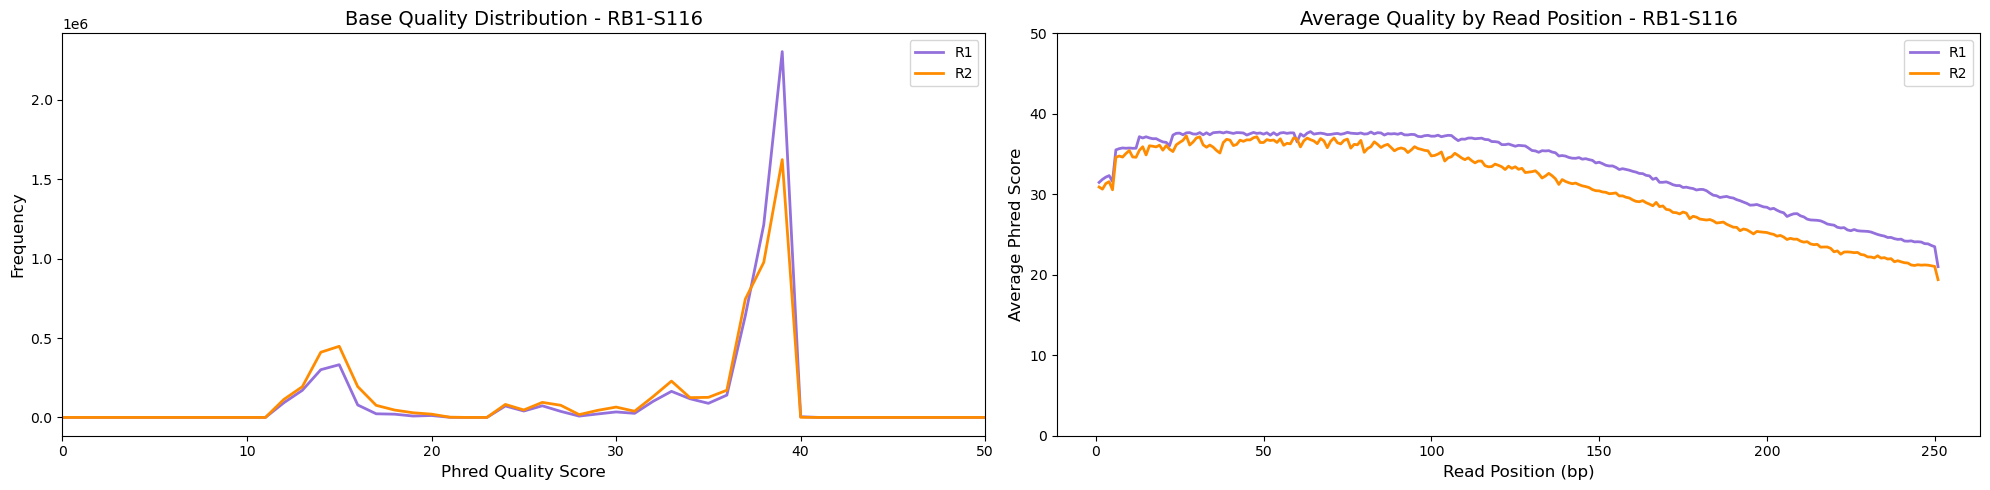

Processing fastq qualities for RB2-S151...


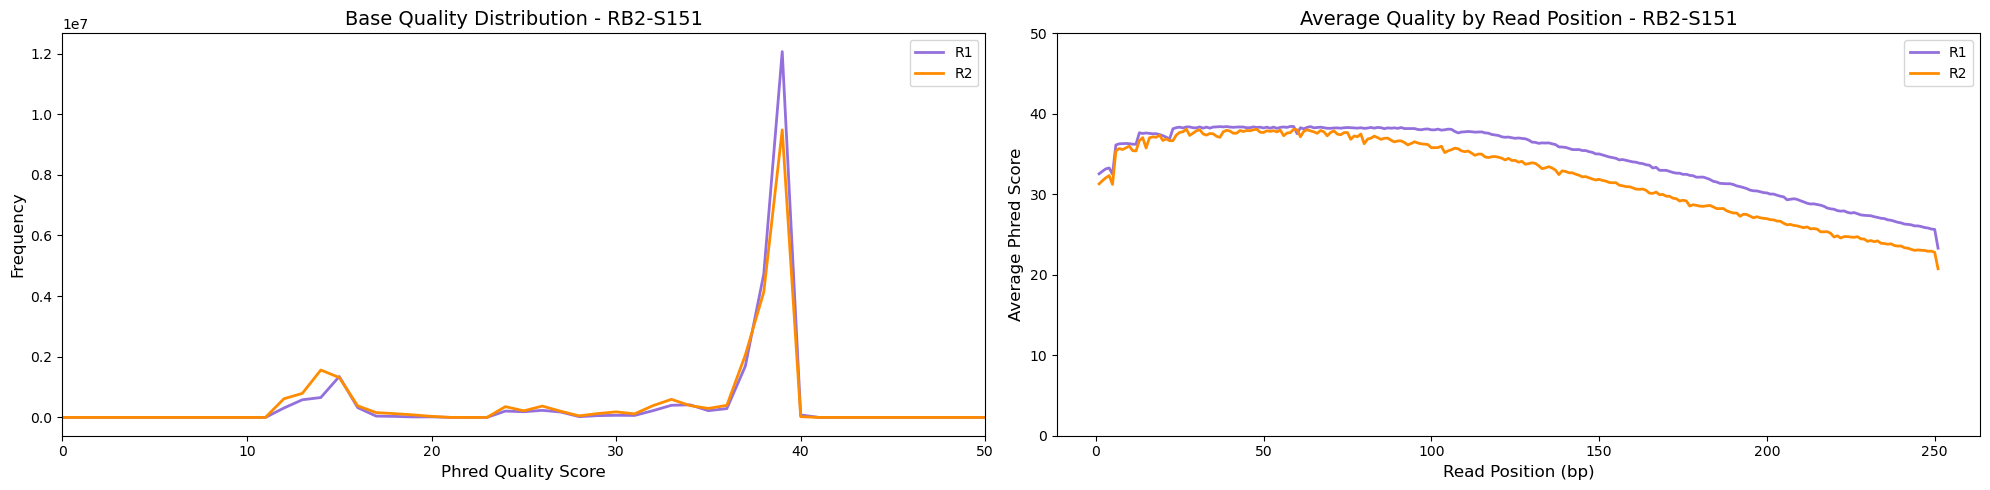

Processing fastq qualities for RB3-S171...


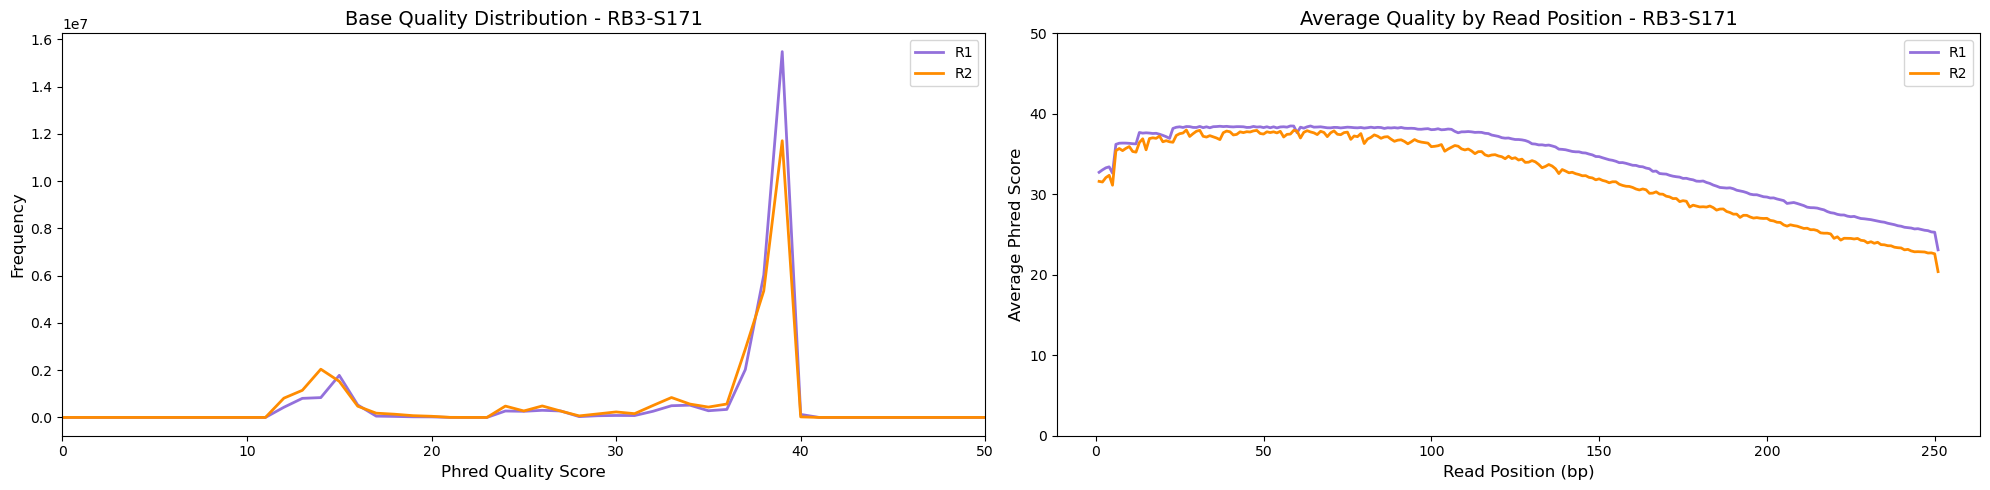

In [48]:
import gzip
import glob
import matplotlib.pyplot as plt
from Bio import SeqIO
from collections import Counter

for sample in samples:
    r1_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R1_001.fastq.gz"))
    r2_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R2_001.fastq.gz"))
    
    if not r1_files or not r2_files: 
        continue
        
    def get_qualities(fastq_file):
        dist_counts = Counter()
        pos_sums = []
        pos_counts = []
        
        with gzip.open(fastq_file, "rt") as handle:
            for record in SeqIO.parse(handle, "fastq"):
                quals = record.letter_annotations["phred_quality"]
                
                # 1. Total Distribution Tracking
                dist_counts.update(quals)
                
                # 2. Positional Tracking
                while len(pos_sums) < len(quals):
                    pos_sums.append(0)
                    pos_counts.append(0)
                for i, q in enumerate(quals):
                    pos_sums[i] += q
                    pos_counts[i] += 1
                    
        avg_quals = [s/c if c > 0 else 0 for s, c in zip(pos_sums, pos_counts)]
        return dist_counts, avg_quals

    print(f"Processing fastq qualities for {sample}...")
    r1_dist, r1_pos = get_qualities(r1_files[0])
    r2_dist, r2_pos = get_qualities(r2_files[0])
    
    scores = list(range(51))
    r1_freqs = [r1_dist.get(s, 0) for s in scores]
    r2_freqs = [r2_dist.get(s, 0) for s in scores]
            
    if sum(r1_freqs) > 0 or sum(r2_freqs) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
        
        # Plot 1: Overall Quality Distribution
        ax1.plot(scores, r1_freqs, label='R1', color='mediumpurple', linewidth=2)
        ax1.plot(scores, r2_freqs, label='R2', color='darkorange', linewidth=2)
        ax1.set_title(f"Base Quality Distribution - {sample}", fontsize=14)
        ax1.set_xlabel("Phred Quality Score", fontsize=12)
        ax1.set_ylabel("Frequency", fontsize=12)
        ax1.set_xlim(0, 50)
        ax1.legend()
        
        # Plot 2: Average Quality By Read Position
        ax2.plot(range(1, len(r1_pos) + 1), r1_pos, label='R1', color='mediumpurple', linewidth=2)
        ax2.plot(range(1, len(r2_pos) + 1), r2_pos, label='R2', color='darkorange', linewidth=2)
        ax2.set_title(f"Average Quality by Read Position - {sample}", fontsize=14)
        ax2.set_xlabel("Read Position (bp)", fontsize=12)
        ax2.set_ylabel("Average Phred Score", fontsize=12)
        ax2.set_ylim(0, 50)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

In [49]:
stats_RB1_S116 = align_and_trim("RB1-S116")

Aligning RB1-S116...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 48834 sequences (12257334 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (4, 24152, 8, 1)
[M::mem_pestat] skip orientation FF as there are not enough pairs
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (92, 144, 219)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 473)
[M::mem_pestat] mean and std.dev: (160.20, 85.37)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 600)
[M::mem_pestat] skip orientation RF as there are not enough pairs
[M::mem_pestat] skip orientation RR as there are not enough pairs
[M::mem_process_seqs] Processed 48834 reads in 3.050 CPU sec, 0.887 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem -t 4 ../primer_schemes/SARS-CoV-2.reference.fasta ../Q11-MG1-SC2/JobID-872/RB1-S116_S11_L001_R1_001.fastq.gz ../Q11-MG1-SC2/JobID-872/RB1-S116_S11_L001_R2_001.fastq.gz
[ma

Trimming primers for RB1-S116...
Found 198 primers in BED file
Reading from ../Q11-MG1-SC2/alignments/RB1-S116.bam
Minimum Read Length based on 1000 reads: 125

-------
Results: 
Primer Name	Read Count
SARS-CoV-2_1_LEFT_1	67
SARS-CoV-2_1_RIGHT_1	75
SARS-CoV-2_2_LEFT_0	32
SARS-CoV-2_2_RIGHT_0	31
SARS-CoV-2_3_LEFT_1	136
SARS-CoV-2_3_RIGHT_0	110
SARS-CoV-2_4_LEFT_0	15
SARS-CoV-2_4_RIGHT_0	6
SARS-CoV-2_5_LEFT_0	4
SARS-CoV-2_5_RIGHT_0	10
SARS-CoV-2_6_LEFT_1	35
SARS-CoV-2_6_RIGHT_1	55
SARS-CoV-2_7_LEFT_2	60
SARS-CoV-2_7_RIGHT_2	81
SARS-CoV-2_8_LEFT_0	22
SARS-CoV-2_8_RIGHT_0	63
SARS-CoV-2_9_LEFT_0	18
SARS-CoV-2_9_RIGHT_0	17
SARS-CoV-2_10_LEFT_0	41
SARS-CoV-2_10_RIGHT_0	13
SARS-CoV-2_11_LEFT_0	9
SARS-CoV-2_11_RIGHT_0	8
SARS-CoV-2_11_RIGHT_1	0
SARS-CoV-2_12_LEFT_0	40
SARS-CoV-2_12_RIGHT_0	64
SARS-CoV-2_13_LEFT_0	72
SARS-CoV-2_13_RIGHT_0	144
SARS-CoV-2_14_LEFT_0	39
SARS-CoV-2_14_RIGHT_0	171
SARS-CoV-2_15_LEFT_0	77
SARS-CoV-2_15_RIGHT_0	111
SARS-CoV-2_16_LEFT_0	111
SARS-CoV-2_16_RIGHT_0	102
SARS-

In [50]:
stats_RB2_S151 = align_and_trim("RB2-S151")

Aligning RB2-S151...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 159364 sequences (40000364 bp)...
[M::process] read 35684 sequences (8956684 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (14, 78053, 41, 19)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (1187, 3641, 4485)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 11081)
[M::mem_pestat] mean and std.dev: (3322.36, 2464.65)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 14379)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (95, 156, 235)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 515)
[M::mem_pestat] mean and std.dev: (170.08, 91.39)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 655)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75) p

Trimming primers for RB2-S151...
Found 198 primers in BED file
Reading from ../Q11-MG1-SC2/alignments/RB2-S151.bam
Minimum Read Length based on 1000 reads: 124

-------
Results: 
Primer Name	Read Count
SARS-CoV-2_1_LEFT_1	39
SARS-CoV-2_1_RIGHT_1	50
SARS-CoV-2_2_LEFT_0	10
SARS-CoV-2_2_RIGHT_0	220
SARS-CoV-2_3_LEFT_1	1240
SARS-CoV-2_3_RIGHT_0	979
SARS-CoV-2_4_LEFT_0	38
SARS-CoV-2_4_RIGHT_0	0
SARS-CoV-2_5_LEFT_0	0
SARS-CoV-2_5_RIGHT_0	9
SARS-CoV-2_6_LEFT_1	17
SARS-CoV-2_6_RIGHT_1	50
SARS-CoV-2_7_LEFT_2	206
SARS-CoV-2_7_RIGHT_2	278
SARS-CoV-2_8_LEFT_0	15
SARS-CoV-2_8_RIGHT_0	74
SARS-CoV-2_9_LEFT_0	13
SARS-CoV-2_9_RIGHT_0	4
SARS-CoV-2_10_LEFT_0	103
SARS-CoV-2_10_RIGHT_0	57
SARS-CoV-2_11_LEFT_0	9
SARS-CoV-2_11_RIGHT_0	21
SARS-CoV-2_11_RIGHT_1	0
SARS-CoV-2_12_LEFT_0	208
SARS-CoV-2_12_RIGHT_0	245
SARS-CoV-2_13_LEFT_0	112
SARS-CoV-2_13_RIGHT_0	238
SARS-CoV-2_14_LEFT_0	96
SARS-CoV-2_14_RIGHT_0	499
SARS-CoV-2_15_LEFT_0	247
SARS-CoV-2_15_RIGHT_0	375
SARS-CoV-2_16_LEFT_0	988
SARS-CoV-2_16_RIGHT_0	7

In [51]:
stats_RB3_S171 = align_and_trim("RB3-S171")

Aligning RB3-S171...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 159364 sequences (40000364 bp)...
[M::process] read 91456 sequences (22955456 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (21, 78986, 116, 26)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (2749, 3361, 8175)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 19027)
[M::mem_pestat] mean and std.dev: (4694.67, 2741.59)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 24453)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (90, 147, 229)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 507)
[M::mem_pestat] mean and std.dev: (165.20, 94.35)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 646)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75)

Trimming primers for RB3-S171...
Found 198 primers in BED file
Reading from ../Q11-MG1-SC2/alignments/RB3-S171.bam
Minimum Read Length based on 1000 reads: 122

-------
Results: 
Primer Name	Read Count
SARS-CoV-2_1_LEFT_1	226
SARS-CoV-2_1_RIGHT_1	226
SARS-CoV-2_2_LEFT_0	205
SARS-CoV-2_2_RIGHT_0	213
SARS-CoV-2_3_LEFT_1	446
SARS-CoV-2_3_RIGHT_0	357
SARS-CoV-2_4_LEFT_0	218
SARS-CoV-2_4_RIGHT_0	181
SARS-CoV-2_5_LEFT_0	96
SARS-CoV-2_5_RIGHT_0	209
SARS-CoV-2_6_LEFT_1	251
SARS-CoV-2_6_RIGHT_1	412
SARS-CoV-2_7_LEFT_2	284
SARS-CoV-2_7_RIGHT_2	298
SARS-CoV-2_8_LEFT_0	70
SARS-CoV-2_8_RIGHT_0	286
SARS-CoV-2_9_LEFT_0	720
SARS-CoV-2_9_RIGHT_0	419
SARS-CoV-2_10_LEFT_0	322
SARS-CoV-2_10_RIGHT_0	211
SARS-CoV-2_11_LEFT_0	550
SARS-CoV-2_11_RIGHT_0	724
SARS-CoV-2_11_RIGHT_1	0
SARS-CoV-2_12_LEFT_0	446
SARS-CoV-2_12_RIGHT_0	335
SARS-CoV-2_13_LEFT_0	223
SARS-CoV-2_13_RIGHT_0	649
SARS-CoV-2_14_LEFT_0	332
SARS-CoV-2_14_RIGHT_0	1685
SARS-CoV-2_15_LEFT_0	418
SARS-CoV-2_15_RIGHT_0	437
SARS-CoV-2_16_LEFT_0	605
SAR

## Alignment Statistics
Calculate and display the number and fraction of mapped reads for each sample using `samtools flagstat` and `ivar trim` logs.

In [52]:
results = []

ivar_stats_list = [stats_RB1_S116, stats_RB2_S151, stats_RB3_S171]
ivar_stats_dict = {s["Sample"]: s for s in ivar_stats_list if s}

for sample in samples:
    raw_bam = os.path.join(out_dir, f"{sample}.bam")
    trim_bam = os.path.join(out_dir, f"{sample}.trimmed.sorted.bam")
    
    if not os.path.exists(raw_bam):
        continue
        
    res_raw = subprocess.run(["samtools", "flagstat", raw_bam], capture_output=True, text=True, check=True)
    total_reads = 0
    mapped_reads = 0
    for line in res_raw.stdout.split('\n'):
        if "in total" in line:
            total_reads = int(line.split(' + ')[0])
        elif "mapped (" in line:
            mapped_reads = int(line.split(' + ')[0])
            break
    
    trimmed_reads = 0
    if os.path.exists(trim_bam):
        res_trim = subprocess.run(["samtools", "flagstat", trim_bam], capture_output=True, text=True, check=True)
        for line in res_trim.stdout.split('\n'):
            if "mapped (" in line:
                trimmed_reads = int(line.split(' + ')[0])
                break
                
    total = total_reads
    
    unmapped = total - mapped_reads
    unmapped_str = f"{unmapped} ({(unmapped/total):.1%})" if total > 0 else "0 (0%)"
    
    qual = ivar_stats_dict.get(sample, {}).get("Quality Trimmed (reads)", 0)
    qual_str = f"{qual} ({(qual/total):.1%})" if total > 0 else "0 (0%)"
    
    outside = ivar_stats_dict.get(sample, {}).get("Outside Primer Regions (reads)", 0)
    outside_str = f"{outside} ({(outside/total):.1%})" if total > 0 else "0 (0%)"
    
    row = {
        "Sample": sample,
        "Total Reads": total,
        "Unmapped": unmapped_str,
        "Quality Trimmed": qual_str,
        "Outside Primer": outside_str,
        "Final Trimmed Reads": trimmed_reads
    }
    results.append(row)

df = pd.DataFrame(results)
display(df)

,Sample,Total Reads,Unmapped,Quality Trimmed,Outside Primer,Final Trimmed Reads
0,RB1-S116,49053,301 (0.6%),23370 (47.6%),17216 (35.1%),8164
1,RB2-S151,195901,3030 (1.5%),79720 (40.7%),75268 (38.4%),37881
2,RB3-S171,254168,677 (0.3%),111195 (43.7%),99676 (39.2%),42618


## Primer Coverage Statistics
Generate a table and bar chart showing reads per primer based on `ivar trim` output.

Sample,RB1-S116,RB2-S151,RB3-S171
Locus,,,
1L,67,39,226
1R,75,50,226
2L,32,10,205
2R,31,220,213
3L,136,1240,446
3R,110,979,357
4L,15,38,218
4R,6,0,181
5L,4,0,96


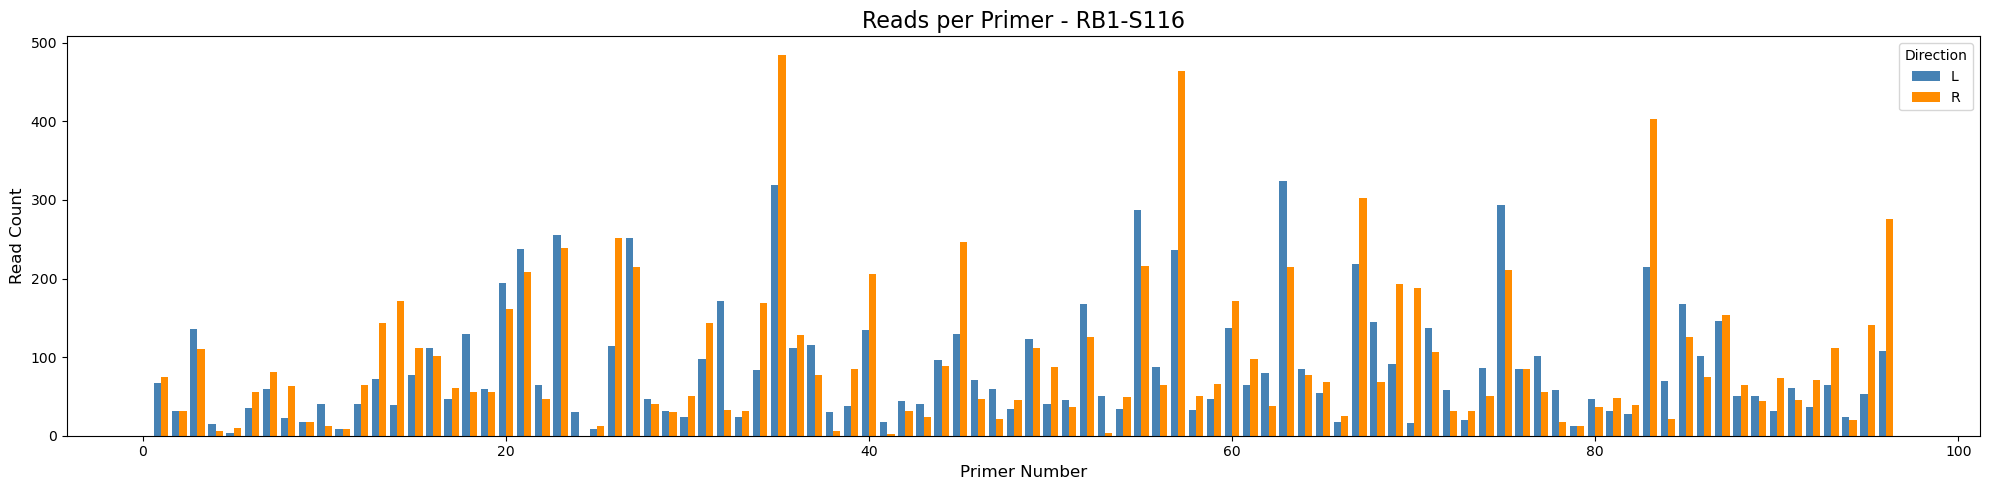

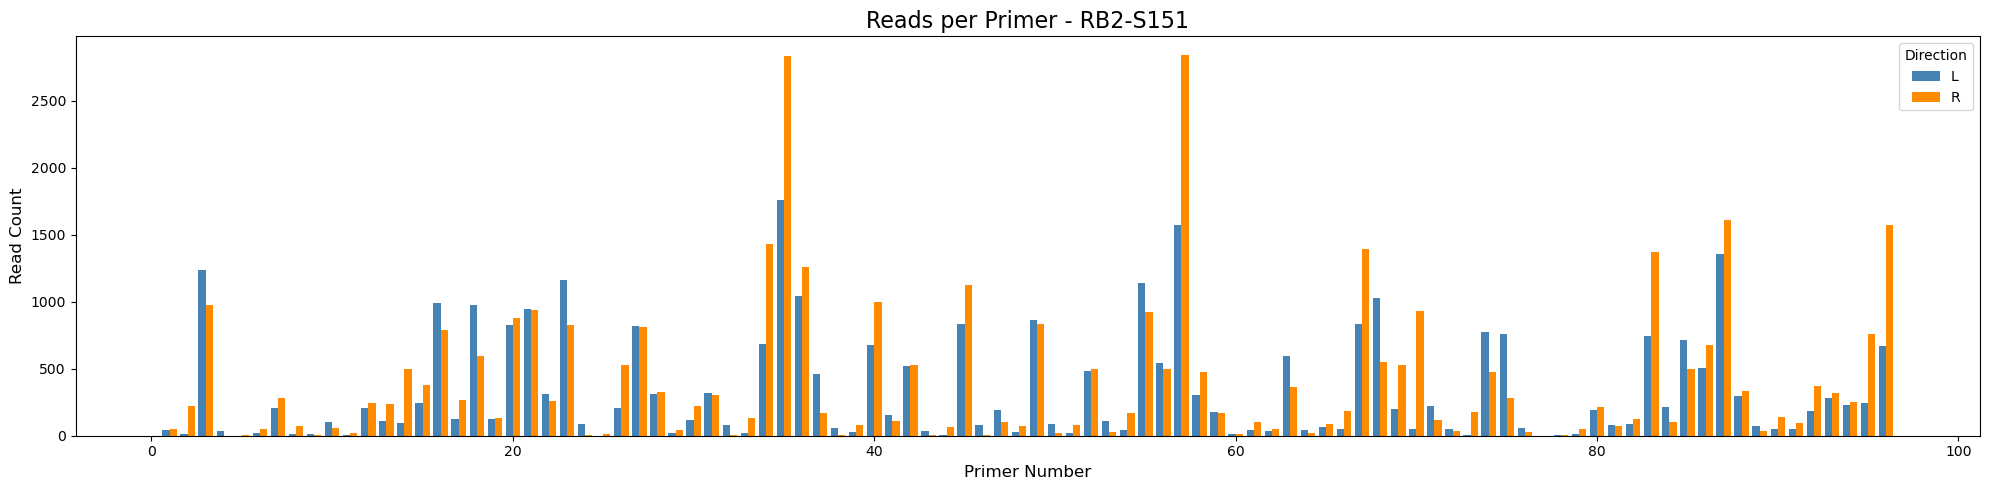

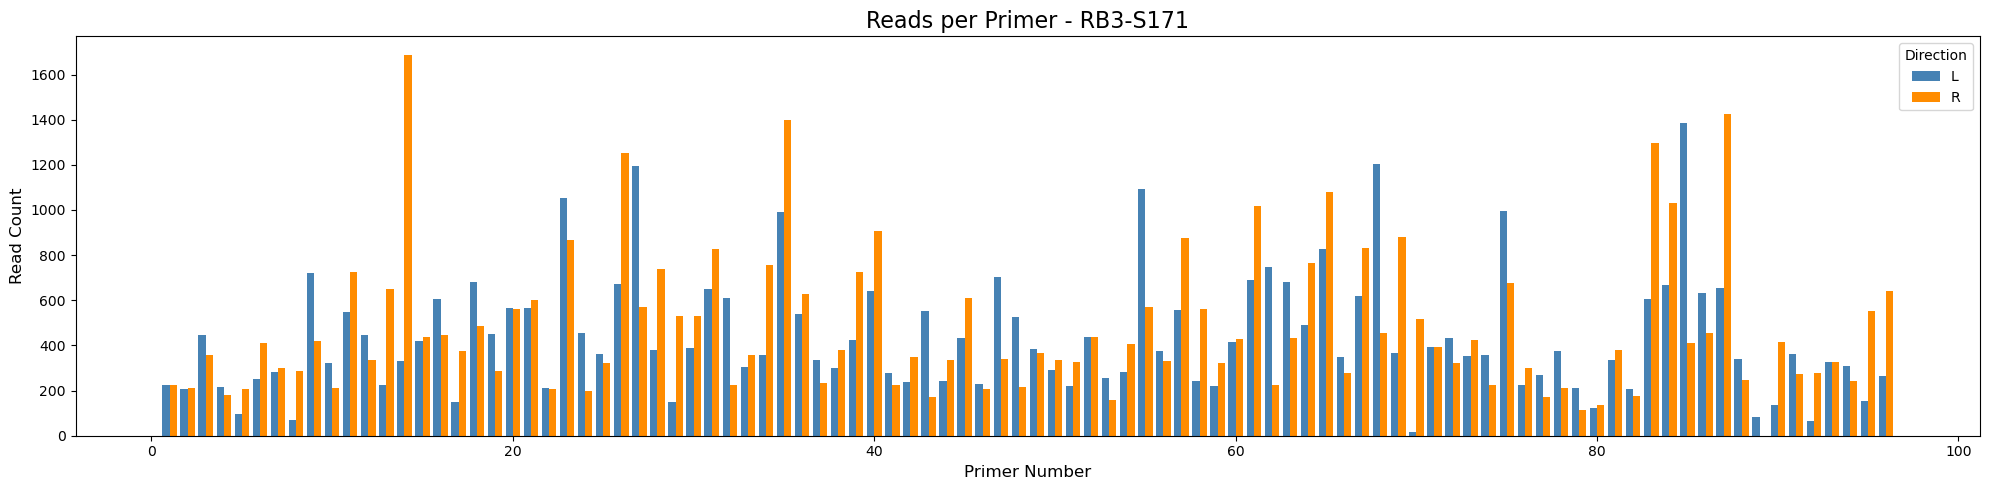

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import re

primer_data = []

# Build dataset directly from captured ivar primer counts
for sample in samples:
    if sample in ivar_stats_dict and "Primer_Counts" in ivar_stats_dict[sample]:
        for primer, count in ivar_stats_dict[sample]["Primer_Counts"].items():
            match = re.search(r'SARS-CoV-2_(\d+)_(LEFT|RIGHT)', primer)
            if match:
                num = int(match.group(1))
                direction = match.group(2)[0]
                locus = f"{num}{direction}"
                primer_data.append({
                    "Sample": sample,
                    "Primer_Num": num,
                    "Direction": direction,
                    "Locus": locus,
                    "Read Count": count
                })

df_primers = pd.DataFrame(primer_data)

if not df_primers.empty:
    # Group and sum the Read Counts by Sample and Locus to combine variants (e.g. 84_RIGHT_3 and 84_RIGHT_2)
    df_grouped = df_primers.groupby(["Sample", "Primer_Num", "Direction", "Locus"])["Read Count"].sum().reset_index()
    
    # Display Table showing the summed locus counts
    df_pivot_table = df_grouped.pivot(index="Locus", columns="Sample", values="Read Count").fillna(0)
    
    def locus_sort_key(locus):
        match = re.match(r'(\d+)([LR])', locus)
        if match:
            return (int(match.group(1)), match.group(2))
        return (0, locus)
        
    df_pivot_table['sort_key'] = [locus_sort_key(idx) for idx in df_pivot_table.index]
    df_pivot_table = df_pivot_table.sort_values('sort_key').drop('sort_key', axis=1)
    
    with pd.option_context('display.max_rows', None):
        display(df_pivot_table)
        
    # Draw grouped numeric Bar Charts
    for sample in samples:
        sample_data = df_grouped[df_grouped["Sample"] == sample]
        if sample_data.empty:
            continue
            
        df_sample_pivot = sample_data.pivot(index="Primer_Num", columns="Direction", values="Read Count").fillna(0)
        
        fig, ax = plt.subplots(figsize=(20, 5))
        
        if 'L' in df_sample_pivot.columns:
            ax.bar(df_sample_pivot.index - 0.2, df_sample_pivot['L'], width=0.4, color='steelblue', label='L')
        if 'R' in df_sample_pivot.columns:
            ax.bar(df_sample_pivot.index + 0.2, df_sample_pivot['R'], width=0.4, color='darkorange', label='R')
            
        ax.set_title(f"Reads per Primer - {sample}", fontsize=16)
        ax.set_xlabel("Primer Number", fontsize=12)
        ax.set_ylabel("Read Count", fontsize=12)
        ax.legend(title="Direction")
        
        plt.tight_layout()
        plt.show()

else:
    print("No primer depth data found from ivar output.")

## Consensus Sequence
Generate a consensus sequence for each sample using `samtools mpileup` and `ivar consensus`, then calculate the frequency of 'N's.

In [54]:
cons_RB1_S116 = generate_consensus("RB1-S116")

Generating consensus for RB1-S116...
Minimum Quality: 20
Threshold: 0
Minimum depth: 10
Minimum Insert Threshold: 0.8
Regions with depth less than minimum depth covered by: N


[mpileup] 1 samples in 1 input files
<mpileup> Set max per-file depth to 8000


Reference length: 29903
Positions with 0 depth: 916
Positions with depth below 10: 5638


In [55]:
cons_RB2_S151 = generate_consensus("RB2-S151")

Generating consensus for RB2-S151...
Minimum Quality: 20
Threshold: 0
Minimum depth: 10
Minimum Insert Threshold: 0.8
Regions with depth less than minimum depth covered by: N


[mpileup] 1 samples in 1 input files
<mpileup> Set max per-file depth to 8000


Reference length: 29903
Positions with 0 depth: 2696
Positions with depth below 10: 6087


In [56]:
cons_RB3_S171 = generate_consensus("RB3-S171")

Generating consensus for RB3-S171...
Minimum Quality: 20
Threshold: 0
Minimum depth: 10
Minimum Insert Threshold: 0.8
Regions with depth less than minimum depth covered by: N


[mpileup] 1 samples in 1 input files
<mpileup> Set max per-file depth to 8000


Reference length: 29903
Positions with 0 depth: 223
Positions with depth below 10: 245


### Consensus Statistics

In [57]:
consensus_stats = [s for s in [cons_RB1_S116, cons_RB2_S151, cons_RB3_S171] if s]
df_consensus = pd.DataFrame(consensus_stats)
display(df_consensus)

,Sample,Total Length,N Count,Coverage
0,RB1-S116,29847,5638,0.8111
1,RB2-S151,29847,6087,0.7961
2,RB3-S171,29799,245,0.9918
